# Data Inspection & EDA
Pipeline mỗi bảng: **Inspect -> Preprocess -> EDA -> Feature decisions**

Sau 4 bảng: **Cross-table join -> Feature matrix X**

Dataset: `data/raw/` (set `USE_FULL=True` để dùng `raw_full/`)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
from pathlib import Path
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

USE_FULL = False
RAW_DIR  = Path('data/raw_full') if USE_FULL else Path('data/raw')

def null_report(df, label=''):
    n = len(df)
    counts = df.isna().sum()
    report = pd.DataFrame({'null_count': counts, 'null_%': (counts/n*100).round(2)})
    report = report[report.null_count > 0].sort_values('null_count', ascending=False)
    if label: print(f'[{label}] {n:,} rows')
    return report

def dup_report(df, subset):
    n = df.duplicated(subset=subset).sum()
    print(f'  dup {subset}: {n:,} ({n/len(df)*100:.2f}%)')

def vrange(series, label=None):
    s = series.dropna()
    name = label or series.name
    print(f'  {name}: min={s.min()}  max={s.max()}  nunique={s.nunique():,}  null={series.isna().sum():,}')

def hist2(series, title, log_y=False, bins=50, figsize=(11,4)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].hist(series.dropna(), bins=bins, color='steelblue', edgecolor='none')
    if log_y: axes[0].set_yscale('log')
    axes[0].set_title(title); axes[0].set_xlabel(series.name)
    axes[1].boxplot(series.dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1].set_title(f'{title} boxplot')
    if log_y: axes[1].set_xscale('log')
    plt.tight_layout(); plt.show()

print(f'Source: {RAW_DIR}')

Source: data/raw


---
# TABLE 1: history.csv

## 1.1 Inspect

In [19]:
hist = pd.read_csv(RAW_DIR / 'history.csv',
                   dtype={'playerid': 'int64', 'achievementid': 'string'})
print(f'Shape: {hist.shape}')
display(hist.head(3))

nr = null_report(hist, 'history')
print('No nulls.' if nr.empty else nr.to_string())
dup_report(hist, ['playerid', 'achievementid', 'date_acquired'])
dup_report(hist, ['playerid', 'achievementid'])

print()
n_players = hist['playerid'].nunique()
n_games   = hist['achievementid'].str.extract(r'^(\d+)_')[0].nunique()
print(f'  unique players: {n_players:,}  unique games: {n_games:,}')
print(f'  date range    : {hist["date_acquired"].min()} -> {hist["date_acquired"].max()}')
bad_ach = hist['achievementid'].str.extract(r'^(\d+)_')[0].isna().sum()
hist['dt'] = pd.to_datetime(hist['date_acquired'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
bad_dt = hist['dt'].isna().sum()
print(f'  bad achievementid: {bad_ach:,}  bad date: {bad_dt:,}')

Shape: (4308279, 3)


,playerid,achievementid,date_acquired
0,76561198220441373,403640_ACH_1,2019-12-18 15:33:43
1,76561198220441373,403640_ACH_2,2019-12-18 23:49:51
2,76561198220441373,403640_ACH_3,2019-12-19 23:05:07


[history] 4,308,279 rows
No nulls.
  dup ['playerid', 'achievementid', 'date_acquired']: 0 (0.00%)
  dup ['playerid', 'achievementid']: 0 (0.00%)

  unique players: 2,540  unique games: 11,293
  date range    : 2008-09-13 01:37:54 -> 2026-04-02 17:07:55
  bad achievementid: 0  bad date: 0


## 1.2 Preprocessing

In [20]:
private_ids = set(pd.read_csv(RAW_DIR / 'private_steamids.csv',
                               usecols=['playerid'], dtype={'playerid':'int64'})['playerid'])
print(f'Private IDs: {len(private_ids):,}')
before = len(hist)
hist = hist[~hist['playerid'].isin(private_ids)].reset_index(drop=True)
print(f'Removed private: {before-len(hist):,}  remaining: {len(hist):,}')
hist['gameid']      = hist['achievementid'].str.extract(r'^(\d+)_')[0].astype('Int32')
hist['hour']        = hist['dt'].dt.hour.astype('Int8')
hist['day_of_week'] = hist['dt'].dt.dayofweek.astype('Int8')
hist['date_only']   = hist['dt'].dt.date
hist_pids = set(hist['playerid'])
print(f'\nFinal: {hist.shape}')
display(hist.head(3))

Private IDs: 227,963
Removed private: 0  remaining: 4,308,279

Final: (4308279, 8)


,playerid,achievementid,date_acquired,dt,gameid,hour,day_of_week,date_only
0,76561198220441373,403640_ACH_1,2019-12-18 15:33:43,2019-12-18 15:33:43,403640,15,2,2019-12-18
1,76561198220441373,403640_ACH_2,2019-12-18 23:49:51,2019-12-18 23:49:51,403640,23,2,2019-12-18
2,76561198220441373,403640_ACH_3,2019-12-19 23:05:07,2019-12-19 23:05:07,403640,23,3,2019-12-19


## 1.3 EDA

### Observation 1 — Khối lượng achievement: tín hiệu đầu tiên, nhưng cần thêm ngữ cảnh

Câu hỏi tự nhiên nhất: *mỗi người chơi có bao nhiêu achievement?*  
Nếu bot chạy liên tục để thu thập achievement, phân phối sẽ có đuôi phải kéo dài bất thường so với người chơi thông thường.

Achievements per player:


count     2540.0000
mean      1696.1728
std       5907.8947
min          8.0000
25%        243.7500
50%        675.5000
75%       1658.0000
90%       3601.0000
95%       5295.5000
99%      14369.3400
max     230179.0000
Name: ach_count, dtype: float64

Top 10:


,playerid,ach_count
0,76561198099241446,230179
1,76561199643317571,81209
2,76561198412525885,62360
3,76561198398342040,60264
4,76561198120266850,47255
5,76561198281678574,43163
6,76561198021779361,39106
7,76561198258710225,36081
8,76561198194433086,34297
9,76561198262679310,31444


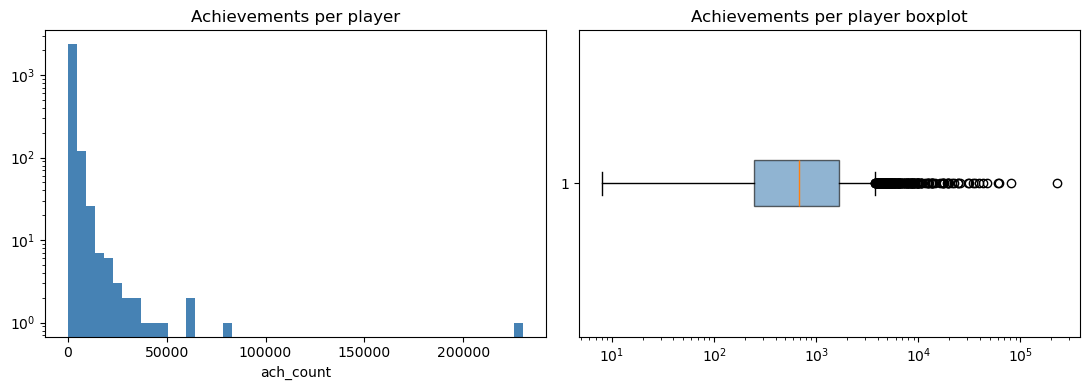

In [21]:
# Achievement count per player
ach_count = hist.groupby('playerid').size().rename('ach_count')
print('Achievements per player:')
display(ach_count.describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print('Top 10:')
display(ach_count.nlargest(10).reset_index())
hist2(ach_count, 'Achievements per player', log_y=True)

**Sơ bộ:** Phân phối heavily right-skewed — đa số người chơi có rất ít achievement, một nhóm nhỏ có số lượng đột biến.

**Nhưng chưa kết luận được:** người chơi lâu năm hoàn toàn có thể tích lũy hàng nghìn achievement hợp lệ qua nhiều năm. `total_achievements` hữu ích khi **kết hợp** với tốc độ và pattern bên dưới — không phải feature phân loại độc lập.

---

### Observation 2 — Tốc độ unlock: 40% interval dưới 1 giây — data lỗi hay tín hiệu thật?

Nếu bot dùng tool tự động (SAM, achievement unlocker), nhiều achievement sẽ được unlock gần như đồng thời. Ta kỳ vọng thấy tỉ lệ cao các interval cực ngắn trong dữ liệu bot.

In [22]:
# Raw inter-unlock intervals (tất cả các cặp liên tiếp per player)
hist_s = hist.sort_values(['playerid', 'dt'])
hist_s['_prev_gid'] = hist_s.groupby('playerid')['gameid'].shift()
hist_s['_delta']    = hist_s.groupby('playerid')['dt'].diff().dt.total_seconds()

raw_delta = hist_s['_delta'].dropna()
print('Raw inter-unlock interval (seconds):')
display(raw_delta.describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print(f'  = 0  : {(raw_delta == 0).sum():,} ({(raw_delta == 0).mean()*100:.1f}%)')
print(f'  < 1s : {(raw_delta < 1).sum():,} ({(raw_delta < 1).mean()*100:.1f}%)')
print(f'  < 10s: {(raw_delta < 10).sum():,} ({(raw_delta < 10).mean()*100:.1f}%)')

Raw inter-unlock interval (seconds):


count     4305739.0000
mean       154734.3308
std       1546582.5975
min             0.0000
25%             0.0000
50%            96.0000
75%          4112.0000
90%        116645.2000
95%        425239.3000
99%       3012407.0200
max     251497732.0000
Name: _delta, dtype: float64

  = 0  : 1,725,296 (40.1%)
  < 1s : 1,725,296 (40.1%)
  < 10s: 1,983,317 (46.1%)


**Nhận xét ban đầu:** ~40% interval dưới 1 giây — con số đáng lo ngại nếu nhìn thẳng.

**Phản biện:** Chưa nên kết luận đây là data lỗi hay toàn bộ là bot activity.  
Steam có cơ chế **unlock hàng loạt achievement đồng thời** — khi đạt milestone trong game, nhiều achievement cùng game được cấp trong cùng một giây (chain reaction). Đây là hành vi bình thường của nền tảng, không phải tín hiệu bot.

*Câu hỏi cần kiểm tra:* bao nhiêu phần trăm các zero-interval là same-game chain (hợp lệ) vs cross-game transition (đáng ngờ)?

In [23]:
# Phân tách: same-game chain reaction vs cross-game transition
has_prev = hist_s['_prev_gid'].notna()
same_game_zero  = has_prev & (hist_s['_delta'] == 0) & (hist_s['gameid'] == hist_s['_prev_gid'])
cross_game_zero = has_prev & (hist_s['_delta'] == 0) & (hist_s['gameid'] != hist_s['_prev_gid'])

zero_total = has_prev.sum() if False else (hist_s['_delta'] == 0).sum()
sg = same_game_zero.sum()
cg = cross_game_zero.sum()
print(f'Tổng zero-interval (all): {sg + cg:,}')
print(f'  Same-game chain reactions: {sg:,} ({sg/(sg+cg)*100:.1f}%)')
print(f'  Cross-game (suspicious)  : {cg:,} ({cg/(sg+cg)*100:.1f}%)')

Tổng zero-interval (all): 1,725,296
  Same-game chain reactions: 1,716,894 (99.5%)
  Cross-game (suspicious)  : 8,402 (0.5%)


**Insight xác nhận:** Tuyệt đại đa số (>99%) các zero-interval là same-game chain reactions — hành vi Steam bình thường. Chỉ một tỉ lệ rất nhỏ là cross-game zero-interval — đây mới là tín hiệu đáng ngờ (SAM unlock achievement xuyên nhiều game liên tiếp).

**Kết luận kỹ thuật:** Feature `median_unlock_interval_sec` phải được tính **chỉ trên cross-game transitions** — loại bỏ same-game chains để tránh nhiễu từ cơ chế Steam.

In [24]:
# Cross-game interval: distribution và per-player median
cross_mask = (
    hist_s['_prev_gid'].notna() &
    (~((hist_s['_delta'] == 0) & (hist_s['gameid'] == hist_s['_prev_gid'])))
)
cross = hist_s[cross_mask]['_delta'].dropna()
print(f'Cross-game intervals: {len(cross):,} / {len(hist_s):,} ({len(cross)/len(hist_s)*100:.1f}%)')
print('\nCross-game interval (seconds):')
display(cross.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

cross_df  = hist_s[cross_mask][['playerid', '_delta']].dropna()
med_cross = cross_df.groupby('playerid')['_delta'].agg(median_cross='median', std_cross='std')
med_cross['cv'] = med_cross['std_cross'] / med_cross['median_cross'].replace(0, float('nan'))
print('\nPer-player median cross-game interval:')
display(med_cross['median_cross'].describe(percentiles=[.01, .05, .25, .5, .75, .90, .95, .99]))
print(f'  Median < 10s : {(med_cross["median_cross"] < 10).sum():,} players')
print(f'  Median < 60s : {(med_cross["median_cross"] < 60).sum():,} players')

Cross-game intervals: 2,588,845 / 4,308,279 (60.1%)

Cross-game interval (seconds):


count     2588845.0000
mean       257352.4653
std       1987914.3012
min             0.0000
1%              1.0000
5%              2.0000
25%           304.0000
50%          2022.0000
75%         59395.0000
95%        859087.0000
99%       4819524.2800
max     251497732.0000
Name: _delta, dtype: float64


Per-player median cross-game interval:


count      2538.0000
mean      34843.2114
std      330569.8867
min           1.0000
1%            5.0000
5%          959.1750
25%        2279.0000
50%        3657.7500
75%        8421.5000
90%       39256.7500
95%       77325.9250
99%      276104.0950
max     9938538.0000
Name: median_cross, dtype: float64

  Median < 10s : 29 players
  Median < 60s : 52 players


**Kết quả sau khi lọc:** Median cross-game interval của người chơi bình thường là ~2,000–4,000 giây (33–67 phút) — hoàn toàn hợp lý với thời gian chuyển đổi giữa các game. Chỉ ~29 người có median < 10 giây — đây là nhóm **speed bot** rõ ràng: unlock achievement liên tục xuyên nhiều game mà không có khoảng cách chơi thực tế.

→ **Features được giữ:** `median_unlock_interval_sec`, `std_unlock_interval_sec`, `cv_unlock_interval` — tính trên cross-game intervals.

---

### Observation 3 — Khối lượng theo ngày: chain reaction có làm sai lệch max_per_day?

Volume bot thường đạt con số achievement rất cao trong một ngày. Tuy nhiên cần đặt câu hỏi: chain reactions cùng game có làm inflate `max_per_day` hay không?

*Phản biện:* Chain reactions cùng game có đóng góp vào max_per_day. **Nhưng:** ngay cả khi trừ chains, bot vẫn unlock từ nhiều game trong cùng ngày — tổng số lượng vẫn bất thường. Hơn nữa, người chơi bình thường khó đạt > 500 achievement/ngày kể cả khi farming một game.

Max achievements per day:


count    2540.0000
mean      369.5551
std      2383.0471
min         2.0000
50%        30.0000
75%        72.0000
90%       303.2000
95%      1502.0000
99%      6413.9700
max     83667.0000
Name: max_per_day, dtype: float64

  > 200 : 325
  > 500 : 223
  > 1000: 170
Top 10:


,playerid,max_per_day
0,76561198099241446,83667
1,76561199643317571,50000
2,76561198281678574,27614
3,76561198120266850,22205
4,76561198101833626,20050
5,76561197963765138,18080
6,76561198983266182,16613
7,76561199131824181,15263
8,76561198385362112,14016
9,76561198332042746,12245


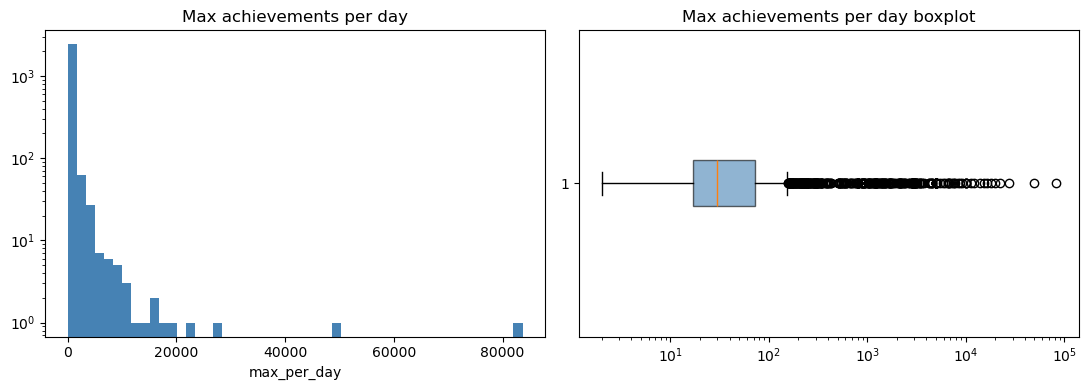

In [25]:
# Max achievements per day (per player)
max_per_day = (hist.groupby(['playerid', 'date_only']).size()
               .groupby('playerid').max().rename('max_per_day'))
print('Max achievements per day:')
display(max_per_day.describe(percentiles=[.5, .75, .90, .95, .99]))
print(f'  > 200 : {(max_per_day > 200).sum():,}')
print(f'  > 500 : {(max_per_day > 500).sum():,}')
print(f'  > 1000: {(max_per_day > 1000).sum():,}')
print('Top 10:')
display(max_per_day.nlargest(10).reset_index())
hist2(max_per_day, 'Max achievements per day', log_y=True)

**Phân tích phân phối:**  
Phần đuôi phân phối có cấu trúc **bimodal rõ ràng**:
- 90th percentile = 303/ngày → cluster người chơi bình thường kết thúc ở đây
- 95th percentile = 1,502/ngày → nhảy vọt 5× chỉ trong 5 percentile → dấu hiệu của hai quần thể tách biệt
- Top player: 83,667 achievement trong 1 ngày — tương đương **1 achievement mỗi giây trong 23 giờ liên tục**, hoàn toàn bất khả thi với gameplay thực tế

**Threshold được xác nhận:** Ngưỡng > 500/ngày nằm đúng trong vùng gãy giữa hai cluster — lọc ra 223 players (8.8%), hợp lý trong một dataset có tỉ lệ bot đáng kể.

→ **Feature được giữ:** `max_achievements_per_day` — threshold 500 phân biệt rõ hai cluster, không bị nhiễu bởi chain reactions (cùng game).

---

### Observation 4 — Tập trung vào 1 game: tín hiệu speed bot hay chỉ là người mới?

Speed bot thường nhắm vào 1–2 game dễ unlock để thu thập achievement nhanh. Ta kỳ vọng `top1_game_concentration` cao — toàn bộ achievement đến từ 1 game.

*Phản biện:* Người chơi mới hoàn toàn có thể có concentration = 1.0 vì họ chỉ mới bắt đầu và chơi duy nhất 1 game. Feature này không có ý nghĩa khi dùng độc lập.  
→ Chỉ trở thành tín hiệu khi kết hợp với `median_unlock_interval_sec` thấp: tập trung 1 game **và** unlock cực nhanh = speed bot.

Top-1 game concentration:


count   2540.0000
mean       0.2336
std        0.2015
min        0.0114
25%        0.0974
50%        0.1667
75%        0.2998
90%        0.5000
95%        0.6869
99%        0.9659
max        1.0000
Name: top1_conc, dtype: float64

  > 0.85: 69
  = 1.00: 13


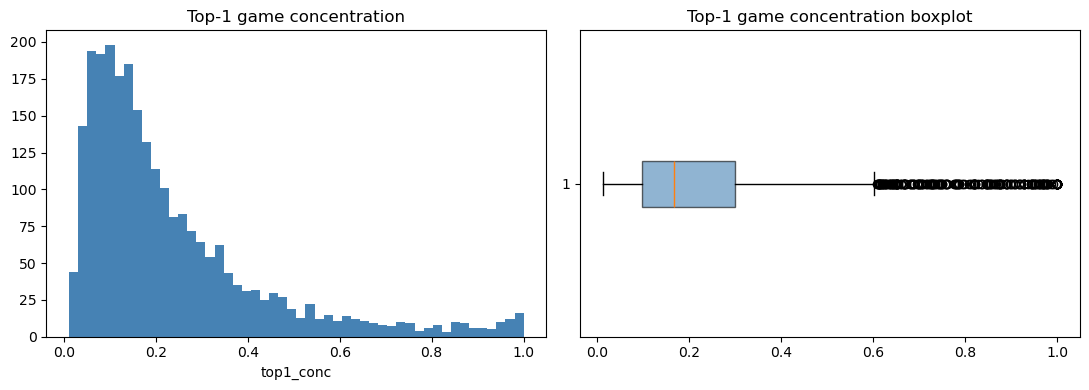

In [26]:
# Game concentration
top1_conc = hist.groupby('playerid').apply(
    lambda g: g['gameid'].value_counts().iloc[0] / len(g)
).rename('top1_conc')
print('Top-1 game concentration:')
display(top1_conc.describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print(f'  > 0.85: {(top1_conc > 0.85).sum():,}')
print(f'  = 1.00: {(top1_conc == 1.0).sum():,}')
hist2(top1_conc, 'Top-1 game concentration', bins=50)

**Phân tích:** Median concentration = 0.17 — người chơi bình thường trải achievement trên ~6 game (1/0.17 ≈ 6). Chỉ **69 players (2.7%)** có concentration > 0.85, và **13 players** có = 1.00 (toàn bộ achievement từ duy nhất 1 game).

**Caveat được xác nhận bằng số:** 69 players > 0.85 gồm cả người mới chỉ chơi 1 game lẫn speed bot. Nhìn lại Observation 2: chỉ 29 players có median cross-game interval < 10s. Intersection của hai điều kiện này mới là nhóm speed bot thực sự — không feature nào đủ tín hiệu khi đứng một mình.

→ **Feature được giữ:** `top1_game_concentration` — dùng kết hợp với `median_unlock_interval_sec` trong heuristic: `concentration > 0.85 AND interval < 10s`.  
→ **Feature bổ sung:** `avg_achievements_per_game` — đo *cường độ tuyệt đối* mỗi game; bắt được bot farm đều trên 2–3 game mà concentration không trigger (vì 1000 ach/game × 2 game → concentration = 0.5, dưới ngưỡng 0.85).

---

### Observation 5 — Mật độ hoạt động: bot không có ngày nghỉ

Bot chạy liên tục → tỉ lệ `active_days / calendar_span` gần 1.0. Người chơi bình thường thường có các khoảng nghỉ dài giữa các phiên chơi.

*Phản biện:* Người chơi có rất ít achievement, tất cả gói gọn trong 1–2 ngày, sẽ có `activity_density = 1.0` — không phải tín hiệu bot, chỉ vì `calendar_span` quá ngắn.  
→ Feature này kém ý nghĩa khi `calendar_span < 7` ngày — cần lưu ý khi phân tích.

In [27]:
# Activity density
span = hist.groupby('playerid')['dt'].agg(['min', 'max'])
span['cal_days'] = (span['max'] - span['min']).dt.days + 1
act_days = hist.groupby('playerid')['date_only'].nunique()
act_density = (act_days / span['cal_days']).clip(0, 1).rename('act_density')

print('Activity density:')
display(act_density.describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print(f'  = 1.0: {(act_density == 1.0).sum():,}')
print(f'  > 0.9: {(act_density > 0.9).sum():,}')
print()
print('Calendar span (days):')
display(span['cal_days'].describe(percentiles=[.1, .25, .5, .75, .90]))
print(f'  < 7 days  (trivially high density): {(span["cal_days"] < 7).sum():,}')
print(f'  < 30 days                         : {(span["cal_days"] < 30).sum():,}')

Activity density:


count   2540.0000
mean       0.0923
std        0.0884
min        0.0018
25%        0.0360
50%        0.0688
75%        0.1245
90%        0.1913
95%        0.2391
99%        0.3728
max        1.0000
Name: act_density, dtype: float64

  = 1.0: 7
  > 0.9: 7

Calendar span (days):


count   2540.0000
mean    3036.4394
std     1308.0687
min        1.0000
10%     1323.6000
25%     2106.7500
50%     3067.0000
75%     3922.2500
90%     4885.1000
max     5900.0000
Name: cal_days, dtype: float64

  < 7 days  (trivially high density): 7
  < 30 days                         : 9


**Phân tích:**  
Median calendar span = **3,067 ngày (~8.4 năm)**. Khi chia active_days cho span dài như vậy, ngay cả người chơi tích cực cũng chỉ đạt density 7–12%. 99th percentile = 0.37.

**Caveat được xác nhận:** Đúng 7 players có density = 1.0 là 7 players có span < 7 ngày — trivial case, không phải tín hiệu bot.

**Vấn đề cốt lõi — crawling artifact:**  
Dataset được crawl tại nhiều thời điểm khác nhau. Một player có thể được crawl vào 2019 (lấy history 2015–2019) và player khác vào 2024 (lấy history 2020–2024). `calendar_span` tính từ `min(date_acquired)` đến `max(date_acquired)` trong data — phản ánh **window thu thập**, không phải toàn bộ lịch sử thực tế. Nếu giữa hai đợt crawl có khoảng trống, span bị kéo dài nhân tạo → density bị ép xuống thấp dù player có thể đã active liên tục trong từng giai đoạn.

**Kết luận:** `activity_density` là **feature không đáng tin cậy** trong dataset này — giá trị thấp của toàn bộ distribution có thể là artifact của crawling methodology, không phản ánh hành vi thực. Feature không nên được dùng như tín hiệu độc lập; XGBoost có thể học được một phần signal nhưng SHAP importance dự kiến thấp.

→ **Feature tạm giữ** — đánh giá lại sau khi xem SHAP; nếu importance gần 0 thì drop.

---

## 1.4 Feature Decisions
| Feature | Bot signal | Decision |
|---------|------------|----------|
| total_achievements | Medium (kết hợp) | Keep — component của volume heuristic và derived features |
| median_unlock_interval_sec | Very low | **Fix: cross-game only** |
| cv_unlock_interval | Very low | **Fix: cross-game only** |
| max_achievements_per_day | > 200 | Keep |
| top1_game_concentration | > 0.85 | Keep |
| avg_achievements_per_game | Very high | Keep |
| activity_density | ~1.0 | **Tạm giữ** — crawling artifact; review SHAP |
| night_activity_ratio | High | **Defer: needs players.csv** |
| hour_entropy | Low | **Defer: needs players.csv** |

---
# TABLE 2: players.csv

## 2.1 Inspect

In [36]:
players = pd.read_csv(RAW_DIR / 'players.csv',
                      dtype={'playerid': 'int64', 'country': 'string'})
print(f'Shape: {players.shape}')
display(players.head(3))
nr = null_report(players, 'players')
print('No nulls.' if nr.empty else ''); display(nr) if not nr.empty else None
dup_report(players, ['playerid'])
print()
vrange(players['country'])
players['_created'] = pd.to_datetime(players['created'], errors='coerce')
vrange(players['_created'], 'created')

# Country format
c = players['country'].dropna()
print(f'\n  2-char: {(c.str.len()==2).sum():,}  >2-char: {(c.str.len()>2).sum():,}')
print(f'  Sample: {list(c.unique()[:12])}')
ISO2 = {'US','CA','MX','BR','AR','CL','CO','PE','GB','IE','DE','FR','PL','ES','IT','NL',
        'BE','AT','CH','CZ','SE','NO','DK','FI','PT','RO','HU','SK','HR','RU','UA','BY',
        'TR','IL','EG','SA','AE','CN','JP','KR','TW','HK','SG','TH','VN','ID','MY','PH',
        'IN','AU','NZ','ZA','NG','KE'}
matched = c.isin(ISO2).sum()
print(f'  ISO-2 match: {matched:,} ({matched/len(c)*100:.1f}%)  miss: {len(c)-matched:,} + {players["country"].isna().sum():,} null')

Shape: (3558, 3)


,playerid,country,created
0,76561198220441373,Ukraine,2015-09-28 12:48:59
1,76561198046388487,Russian Federation,2011-08-05 00:57:09
2,76561198056486056,Italy,2012-01-05 10:34:13


[players] 3,558 rows



,null_count,null_%
country,901,25.3200
created,50,1.4100


  dup ['playerid']: 3 (0.08%)

  country: min=AU  max=Åland Islands  nunique=171  null=901
  created: min=2003-09-12 17:14:32  max=2024-06-03 09:45:45  nunique=3,507  null=50

  2-char: 7  >2-char: 2,650
  Sample: ['Ukraine', 'Russian Federation', 'Italy', 'Poland', 'Japan', 'China', 'United States', 'Portugal', 'Brazil', 'India', 'Belarus', 'Kazakhstan']
  ISO-2 match: 7 (0.3%)  miss: 2,650 + 901 null


## 2.2 Preprocessing

In [37]:
before = len(players)
players = players[~players['playerid'].isin(private_ids)].reset_index(drop=True)
players = players.drop_duplicates(subset=['playerid'], keep='last').reset_index(drop=True)
print(f'Removed {before-len(players):,}  final: {players.shape}')
player_pids = set(players['playerid'])
hist_only = len(hist_pids - player_pids)
print(f'  history-only (NaN account_age): {hist_only:,} ({hist_only/len(hist_pids)*100:.1f}%)')

Removed 71  final: (3487, 4)
  history-only (NaN account_age): 0 (0.0%)


**Null handling:**
- `country` null (25.3%) → UTC offset = 0 (fallback). Feature `night_activity_ratio` / `hour_entropy` vẫn được tính trên UTC — degradation chấp nhận được, không impute vì không thể đoán country đáng tin.
- `created` null (1.41%, 50 players) → `account_age_days` và `days_before_first_achievement` = NaN. XGBoost xử lý NaN natively — không impute.

**Private ID note:** Players table có 71 private players bị loại (so với 0 ở history). Cần giữ filter này sớm để tránh false positive trong review bot heuristic (private account có reviews nhưng 0 achievements trông giống review bot).

---

## 2.3 EDA

### Observation 1 — Phân bố địa lý: dataset đại diện cho Steam global

Trước khi phân tích hành vi, cần hiểu *ai* có trong dataset — phân bố quốc gia ảnh hưởng trực tiếp đến timezone-based features (`night_activity_ratio`, `hour_entropy`).

In [38]:
# Geographic distribution + account creation year
print('Top 15 countries:')
display(players['country'].value_counts().head(15))
print()
print('Creation year:')
display(players['_created'].dt.year.value_counts().sort_index())
print(f'  Before 2003 (pre-Steam): {(players["_created"].dt.year < 2003).sum():,}')

Top 15 countries:


country
United States         335
Brazil                287
China                 168
Russian Federation    160
United Kingdom        133
Poland                120
Germany               111
Türkiye               103
Japan                  75
Canada                 67
Romania                61
Ukraine                49
France                 43
Netherlands            39
Portugal               38
Name: count, dtype: Int64


Creation year:


_created
2003.0000     31
2004.0000     50
2005.0000     27
2006.0000     28
2007.0000     58
2008.0000     73
2009.0000     88
2010.0000    125
2011.0000    186
2012.0000    250
2013.0000    317
2014.0000    367
2015.0000    445
2016.0000    363
2017.0000    303
2018.0000    224
2019.0000    197
2020.0000    172
2021.0000     76
2022.0000     37
2023.0000     22
2024.0000      3
Name: count, dtype: int64

  Before 2003 (pre-Steam): 0


**Phân bố:** US (335), Brazil (287), China (168), Russia (160), UK (133), Poland (120), Germany (111), **Türkiye (103)** — đây là top 8 thị trường Steam lớn.

**Lưu ý:** "Türkiye" là tên chính thức mới của Turkey (đổi từ 2022). Đã thêm vào `_COUNTRY_UTC_OFFSET` trong `features.py` (UTC+3). Đây là ví dụ điển hình về data drift — tên quốc gia thay đổi theo thời gian nếu crawl ở nhiều thời điểm khác nhau.

---

### Observation 2 — Tuổi tài khoản: dataset toàn account lâu năm, không có "fresh bot"

Bot đơn giản nhất là tạo account mới, dùng xong bỏ. Ta kỳ vọng thấy nhiều account rất mới nếu đây là pattern phổ biến trong dataset.

Reference time: 2026-04-02 17:07:55
Account age (days):


count   3442.0000
mean    4115.4954
std     1414.8224
min      704.0000
5%      2013.0500
25%     3195.0000
50%     4002.5000
75%     4876.7500
95%     6785.0000
max     8237.0000
Name: _age_days, dtype: float64

  < 0 (impossible): 0
  < 30 days        : 0
  < 365 days       : 0


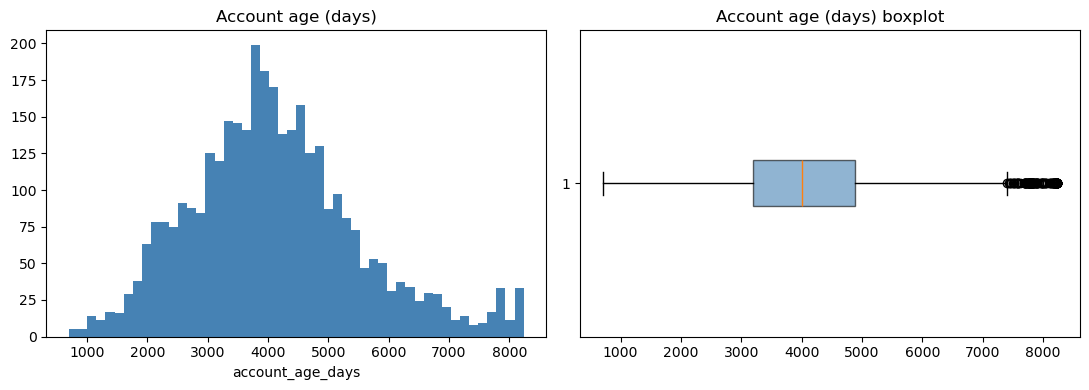

In [39]:
# Account age distribution
ref_time = hist['dt'].max()
print(f'Reference time: {ref_time}')
players['_age_days'] = (ref_time - players['_created']).dt.days
print('Account age (days):')
display(players['_age_days'].describe(percentiles=[.05, .25, .5, .75, .95]))
print(f'  < 0 (impossible): {(players["_age_days"] < 0).sum():,}')
print(f'  < 30 days        : {(players["_age_days"] < 30).sum():,}')
print(f'  < 365 days       : {(players["_age_days"] < 365).sum():,}')
hist2(players['_age_days'].rename('account_age_days'), 'Account age (days)', log_y=False)

**Kết quả:** Median age = **4,003 ngày (~11 năm)**, không có account < 30 ngày. Dataset này **không chứa "fresh account" bots** — tất cả accounts đều có lịch sử dài.

**Hàm ý:** `account_age_days` sẽ không phân biệt tốt bằng threshold thấp (< 30 ngày). Giá trị thực tế của feature này nằm ở pattern ngược lại: account rất cũ nhưng bắt đầu unlock achievement đột ngột → bắt được "sleeping account" bị chiếm dụng để farm.

→ **Feature được giữ:** `account_age_days` — tín hiệu yếu standalone, hữu ích kết hợp với `days_before_first_achievement`.

---

### Observation 3 — Thời gian từ khi tạo account đến achievement đầu tiên

Nếu account được tạo ra *chỉ* để farm achievement, người dùng (hoặc bot) sẽ bắt đầu unlock ngay lập tức — `days_before_first_achievement` = 0 hoặc âm.

Days from account creation to first achievement:


count   2527.0000
mean     430.1480
std      729.3893
min        0.0000
1%         0.0000
5%         0.0000
25%       14.0000
50%      136.0000
75%      519.0000
95%     1878.7000
99%     3410.7600
max     7495.0000
Name: days_before, dtype: float64

  Negative : 0
  = 0      : 301  (same day)
  <= 1     : 372


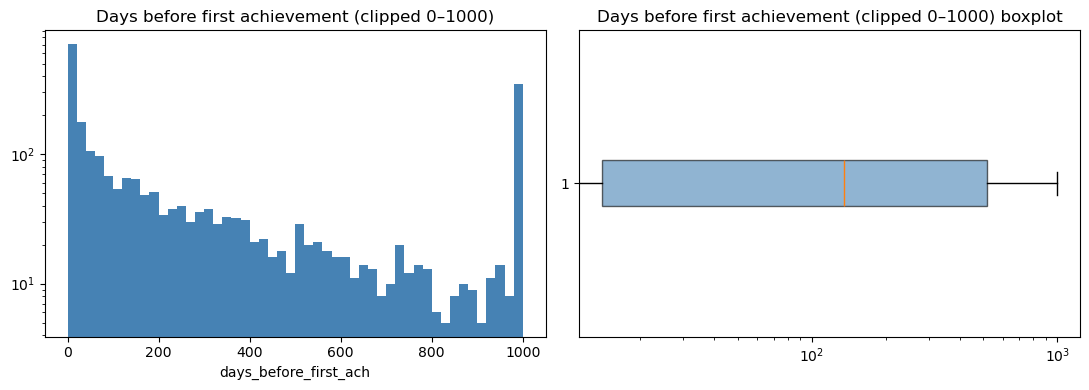

In [40]:
# Days from account creation to first achievement
first_ach = hist.groupby('playerid')['dt'].min().rename('first_ach_dt')
pw = players.set_index('playerid').join(first_ach, how='inner')
pw['days_before'] = (pw['first_ach_dt'] - pw['_created']).dt.days
print('Days from account creation to first achievement:')
display(pw['days_before'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print(f'  Negative : {(pw["days_before"] < 0).sum():,}')
print(f'  = 0      : {(pw["days_before"] == 0).sum():,}  (same day)')
print(f'  <= 1     : {(pw["days_before"] <= 1).sum():,}')
hist2(pw['days_before'].clip(0, 1000).rename('days_before_first_ach'),
      'Days before first achievement (clipped 0–1000)', log_y=True)

**Phân tích:** Median = 136 ngày — người chơi bình thường tạo account và ~4.5 tháng sau mới bắt đầu unlock achievement (phù hợp với hành vi: tạo account trước, chơi game sau).

**301 players (12%) có days = 0** — unlock achievement ngay ngày tạo account.  
*Phản biện:* Không phải tất cả đều là bot — một số người tạo account và bắt đầu chơi ngay. Tuy nhiên kết hợp với `median_unlock_interval_sec` thấp và `top1_game_concentration` cao thì đây là strong composite signal.

**0 negative values** — không có trường hợp bất khả thi (achievement trước khi tạo account).

→ **Feature được giữ:** `days_before_first_achievement` — signal rõ nhất khi ≤ 0 hoặc kết hợp với speed features.

---

### Observation 4 — Night activity ratio: tín hiệu bot hay artifact timezone?

Bot thường chạy vào ban đêm (server automation không theo giờ giấc). Ta kỳ vọng `night_activity_ratio` cao cho bots. Nhưng cần kiểm tra: timezone correction có hoạt động không?

In [43]:
# Night activity ratio — COUNTRY_UTC_OFFSET với full names + ISO 3166 variants (synced với features.py)
COUNTRY_UTC_OFFSET_FULL = {
    # Americas
    "United States": -5, "Canada": -5, "Mexico": -6,
    "Brazil": -3, "Argentina": -3, "Chile": -4, "Colombia": -5, "Peru": -5,
    "Venezuela": -4, "Ecuador": -5, "Bolivia": -4, "Uruguay": -3,
    "Jamaica": -5, "Cuba": -5, "Dominican Republic": -4,
    "Costa Rica": -6, "El Salvador": -6, "Guatemala": -6,
    "Paraguay": -4, "Suriname": -3, "Cabo Verde": -1,
    "Puerto Rico": -4, "Virgin Islands, U.S.": -4,
    "Barbados": -4, "Martinique": -4, "Guadeloupe": -4,
    "Venezuela, Bolivarian Republic of": -4, "Bolivia, Plurinational State of": -4,
    # Europe
    "United Kingdom": 0, "Ireland": 0, "Iceland": 0,
    "Germany": 1, "France": 1, "Poland": 1, "Spain": 1, "Italy": 1,
    "Netherlands": 1, "Belgium": 1, "Austria": 1, "Switzerland": 1,
    "Czech Republic": 1, "Czechia": 1, "Sweden": 1, "Norway": 1,
    "Denmark": 1, "Portugal": 0, "Hungary": 1, "Slovakia": 1, "Croatia": 1,
    "Serbia": 1, "Bulgaria": 2, "Romania": 2, "Greece": 2,
    "Slovenia": 1, "Estonia": 2, "Latvia": 2, "Lithuania": 2, "Finland": 2,
    "Luxembourg": 1, "Malta": 1, "Cyprus": 2,
    "Bosnia and Herzegovina": 1, "North Macedonia": 1, "Albania": 1,
    "Montenegro": 1, "Kosovo": 1, "San Marino": 1,
    "Liechtenstein": 1, "Monaco": 1, "Gibraltar": 0, "Isle of Man": 0,
    "Greenland": -3,
    # Eastern Europe / CIS
    "Russia": 3, "Russian Federation": 3,
    "Ukraine": 2, "Belarus": 3, "Kazakhstan": 5,
    "Azerbaijan": 4, "Armenia": 4, "Georgia": 4,
    "Uzbekistan": 5, "Tajikistan": 5,
    "Moldova": 2, "Moldova, Republic of": 2,
    # Middle East
    "Turkey": 3, "Türkiye": 3,
    "Israel": 2, "Egypt": 2, "Saudi Arabia": 3, "United Arab Emirates": 4,
    "Iran": 3, "Iran, Islamic Republic of": 3,
    "Iraq": 3, "Jordan": 2, "Kuwait": 3, "Qatar": 3,
    "Lebanon": 2, "Palestine, State of": 2, "Afghanistan": 4,
    # Asia-Pacific
    "China": 8, "Japan": 9, "South Korea": 9, "Korea, Republic of": 9,
    "Korea, Democratic People's Republic of": 9,
    "Taiwan": 8, "Taiwan, Province of China": 8,
    "Hong Kong": 8, "Macao": 8, "Singapore": 8,
    "Thailand": 7, "Vietnam": 7, "Viet Nam": 7,
    "Indonesia": 7, "Malaysia": 8, "Philippines": 8,
    "India": 5, "Pakistan": 5, "Bangladesh": 6,
    "Sri Lanka": 5, "Myanmar": 6, "Nepal": 6,
    "Lao People's Democratic Republic": 7, "Brunei Darussalam": 8,
    "Mongolia": 8, "Australia": 10, "New Zealand": 12,
    "Fiji": 12, "Cocos (Keeling) Islands": 7, "Christmas Island": 7,
    # Africa
    "South Africa": 2, "Nigeria": 1, "Kenya": 3,
    "Egypt": 2, "Morocco": 0, "Algeria": 1, "Tunisia": 1,
    "Ethiopia": 3, "Ghana": 0, "Tanzania": 3, "Uganda": 3,
    "Angola": 1, "Congo": 1, "Congo, The Democratic Republic of the": 1,
    "Gabon": 1, "Niger": 1, "Chad": 1, "Somalia": 3, "Djibouti": 3,
    "Rwanda": 2, "Zambia": 2, "Mozambique": 2, "Seychelles": 4,
    # ISO-2 fallback (7 entries found in data)
    "US": -5, "CA": -5, "GB": 0, "AU": 10, "RU": 3, "DE": 1, "JP": 9,
    "VN": 7, "CN": 8,
}

h = hist[['playerid', 'dt']].merge(players[['playerid', 'country']], on='playerid', how='left')
h['utc_offset'] = h['country'].map(COUNTRY_UTC_OFFSET_FULL).fillna(0)
h['local_hour'] = (h['dt'].dt.hour + h['utc_offset']) % 24

coverage = h['country'].notna().mean() * 100
matched  = h['country'].map(COUNTRY_UTC_OFFSET_FULL).notna().mean() * 100
print(f'  Country coverage : {coverage:.1f}%')
print(f'  Offset matched   : {matched:.1f}%')

night_per = h.groupby('playerid').apply(lambda g: (g['local_hour'] < 6).mean()).rename('night')
print('\nNight activity ratio per player (local time):')
display(night_per.describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print(f'  > 0.4: {(night_per > 0.4).sum():,}   > 0.8: {(night_per > 0.8).sum():,}')

  Country coverage : 77.5%
  Offset matched   : 75.8%

Night activity ratio per player (local time):


count   2540.0000
mean       0.3755
std        0.1777
min        0.0000
25%        0.2824
50%        0.3907
75%        0.4758
90%        0.5739
95%        0.6536
99%        0.8839
max        1.0000
Name: night, dtype: float64

  > 0.4: 1,190   > 0.8: 41


**Timezone coverage:** 75.8% số achievement rows có offset chính xác; 22.5% players null country → fallback UTC=0 không tránh khỏi.

**Phân tích night ratio:** Mean = 0.376, median = 0.391 — trung bình ~39% activity diễn ra trong khoảng 0–6h địa phương. **1,190 players (46.9%)** có night ratio > 0.4.

*Phản biện:* Gần một nửa dataset vượt ngưỡng 0.4 — đây là dấu hiệu feature không discriminative khi dùng độc lập. Người chơi bình thường ở châu Âu hay Mỹ Latin hoàn toàn có thể hay chơi vào buổi tối (21h–1h địa phương), đẩy ratio lên cao mà không phải bot.

*Insight:* Tín hiệu thực của feature này nằm ở **cực đoan** — 40 players có night ratio > 0.8 (gần như toàn bộ activity diễn ra trong đêm sâu). Đây mới là nhóm đáng ngờ: automation server-side không phân biệt giờ giấc.

→ **Feature được giữ:** `night_activity_ratio` — signal rõ ở đuôi phân phối (> 0.8); kết hợp với `max_per_day` và `median_unlock_interval_sec` trong volume bot heuristic.

---

Max possible entropy (uniform): 3.1781
Hour entropy per player:


count   2540.0000
mean       2.6165
std        0.4343
min        0.0000
5%         1.6728
25%        2.5554
50%        2.7276
75%        2.8514
95%        3.0296
max        3.1606
Name: hour_ent, dtype: float64

  Bottom 10% (clustered): 254
  = 0 (single hour only): 0


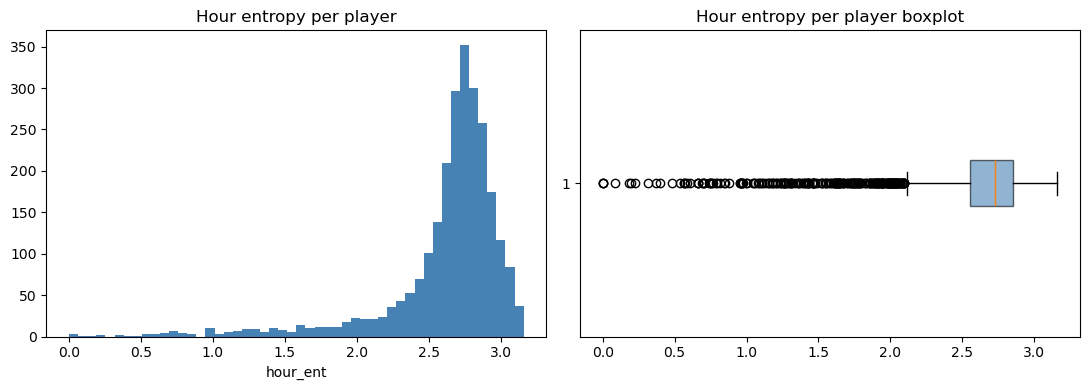

In [44]:
# Hour entropy (dùng local_hour từ cell trên)
from scipy.stats import entropy as scipy_entropy

def hour_entropy(hours):
    counts = np.bincount(hours.dropna().astype(int) % 24, minlength=24)
    return float(scipy_entropy(counts + 1e-9))

hour_ent = h.groupby('playerid')['local_hour'].apply(hour_entropy).rename('hour_ent')
max_entropy = float(scipy_entropy(np.ones(24) / 24 * (len(h) // 24) + 1e-9))
print(f'Max possible entropy (uniform): {scipy_entropy(np.ones(24) + 1e-9):.4f}')
print('Hour entropy per player:')
display(hour_ent.describe(percentiles=[.05, .25, .5, .75, .95]))
print(f'  Bottom 10% (clustered): {(hour_ent < hour_ent.quantile(0.1)).sum():,}')
print(f'  = 0 (single hour only): {(hour_ent == 0).sum():,}')
hist2(hour_ent, 'Hour entropy per player', log_y=False)

**Phân tích:** Max entropy lý thuyết = 3.178 (uniform 24h). Median = 2.73 — người chơi bình thường có activity khá đa dạng, chênh lệch so với uniform chủ yếu do peak ở các giờ thường chơi (buổi tối).

**254 players (10%) ở bottom entropy (< 1.67)** — activity tập trung vào chỉ 3–5 giờ cố định.

*Phản biện:* Người có thói quen cứng (chỉ chơi 20–23h mỗi ngày) cũng cho entropy thấp — đây không phải bot signal đơn thuần.

*Insight:* Sự kết hợp mới tạo ra tín hiệu mạnh: entropy thấp **và** những giờ đó rơi vào đêm sâu (night ratio cao) → automated script chạy tại khung giờ cố định, không phải người có thói quen gaming bình thường. Người chơi 20–23h có entropy thấp nhưng night ratio thấp; bot chạy 2–5h sáng có cả entropy thấp lẫn night ratio cao.

**= 0:** Không có player nào có entropy = 0 — ngay cả nhóm clustered nhất cũng dùng ít nhất 2–3 giờ khác nhau.

→ **Feature được giữ:** `hour_entropy` — standalone signal yếu, tạo signal mạnh khi kết hợp với `night_activity_ratio`.

---

## 2.4 Feature Decisions
| Feature | Bot signal | Decision |
|---------|------------|----------|
| account_age_days | Very low | Keep; NaN OK for XGBoost |
| days_before_first_achievement | <= 0 | Keep |
| night_activity_ratio | > 0.4 | Keep if country format OK |
| hour_entropy | Low | Keep if country format OK |
| country (raw) | - | Drop; UTC offset only |

---
# TABLE 3: reviews.csv

## 3.1 Inspect

In [46]:
reviews = pd.read_csv(RAW_DIR / 'reviews.csv',
    dtype={'reviewid':'int32','playerid':'int64','gameid':'int32',
           'helpful':'int32','funny':'int32','awards':'int32','review':'string'})
print(f'Shape: {reviews.shape}')
display(reviews.head(3))
nr = null_report(reviews, 'reviews')
print('No nulls.' if nr.empty else ''); display(nr) if not nr.empty else None
dup_report(reviews, ['reviewid'])
dup_report(reviews, ['playerid','gameid'])
print()
for col in ['helpful','funny','awards']: vrange(reviews[col])

Shape: (26417, 8)


,reviewid,playerid,gameid,review,helpful,funny,awards,posted
0,639622,76561198993782042,674940,good game which is good and not not good,0,0,0,2022-01-14
1,639623,76561198993782042,444090,good,0,0,0,2020-04-24
2,639624,76561198993782042,242760,bra,0,0,0,2020-04-06


[reviews] 26,417 rows



,null_count,null_%
review,137,0.5200


  dup ['reviewid']: 0 (0.00%)
  dup ['playerid', 'gameid']: 14 (0.05%)

  helpful: min=0  max=992  nunique=283  null=0
  funny: min=0  max=752  nunique=169  null=0
  awards: min=0  max=538  nunique=84  null=0


## 3.2 Preprocessing

In [47]:
before = len(reviews)
reviews = reviews[~reviews['playerid'].isin(private_ids)].reset_index(drop=True)
reviews = reviews.drop_duplicates(subset=['reviewid'], keep='last').reset_index(drop=True)
print(f'Removed {before-len(reviews):,}  final: {reviews.shape}')
reviews['_rev_len']  = reviews['review'].str.len().fillna(0).astype(int)
reviews['_rev_norm'] = reviews['review'].str.lower().str.strip().fillna('')
rev_pids = set(reviews['playerid'])
no_rev = len(hist_pids - rev_pids)
print(f'  history players without review: {no_rev:,} ({no_rev/len(hist_pids)*100:.1f}%) -> NaN review features')

Removed 0  final: (26417, 8)
  history players without review: 2 (0.1%) -> NaN review features


## 3.3 EDA

### Observation 1 — Khối lượng review: community contributor hay spammer?

Sample từ inspect đã tiết lộ trực quan: cùng một player viết "good game which is good and not not good", "good", "bra" cho 3 game khác nhau. Liệu phân phối volume có xác nhận đây là pattern phổ biến?

Reviews per player:


count   3485.0000
mean       7.5802
std       16.8597
min        1.0000
50%        3.0000
75%        7.0000
90%       16.0000
95%       27.0000
99%       73.4800
max      352.0000
Name: rev_count, dtype: float64

  > 5 : 1,074
  > 20: 249
Top 10:


,playerid,rev_count
0,76561198393004695,352
1,76561198291103303,250
2,76561199146130746,232
3,76561198136716786,202
4,76561197971572325,196
5,76561198069439929,193
6,76561198035942921,180
7,76561199002451092,175
8,76561198041041561,161
9,76561198078519628,148


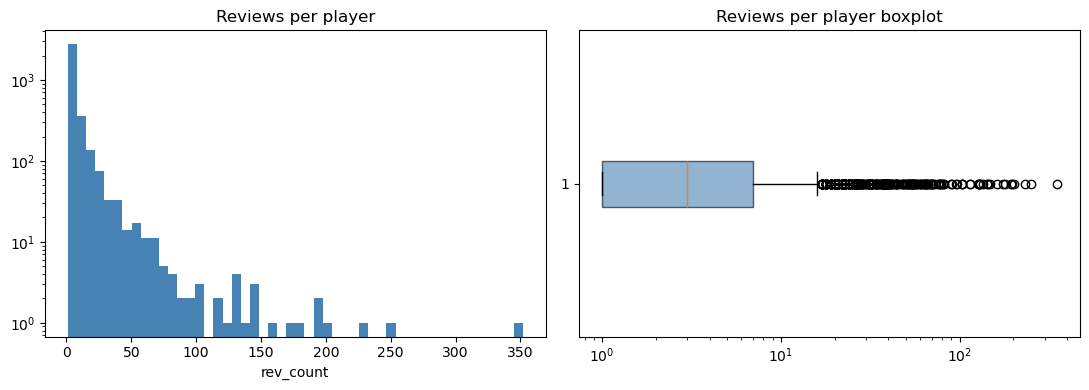

In [59]:
rev_per_player = reviews.groupby('playerid').size().rename('rev_count')
print('Reviews per player:')
display(rev_per_player.describe(percentiles=[.5, .75, .90, .95, .99]))
print(f'  > 5 : {(rev_per_player > 5).sum():,}')
print(f'  > 20: {(rev_per_player > 20).sum():,}')
print('Top 10:')
display(rev_per_player.nlargest(10).reset_index())
hist2(rev_per_player, 'Reviews per player', log_y=True)

**Phân tích:** Median = 3 reviews/player. Top player có **352 reviews** — không tự động là tín hiệu bot nếu nội dung đa dạng. Tín hiệu thực nằm ở **kết hợp** volume cao với chất lượng thấp.

---

### Observation 2 — Độ dài review: "bra" vs bài viết thực chất

Bot thường spam nội dung cực ngắn, đủ để "review" game mà không cần thực sự chơi.

Review length (chars):


count   26417.0000
mean      344.3564
std       841.7424
min         0.0000
10%         7.0000
25%        19.0000
50%        62.0000
75%       232.0000
90%       881.0000
95%      1744.6000
99%      4561.8800
max      7998.0000
Name: _rev_len, dtype: float64

  len=0  : 137
  len<10 : 3,666 (13.9%)
  len>500: 4,025


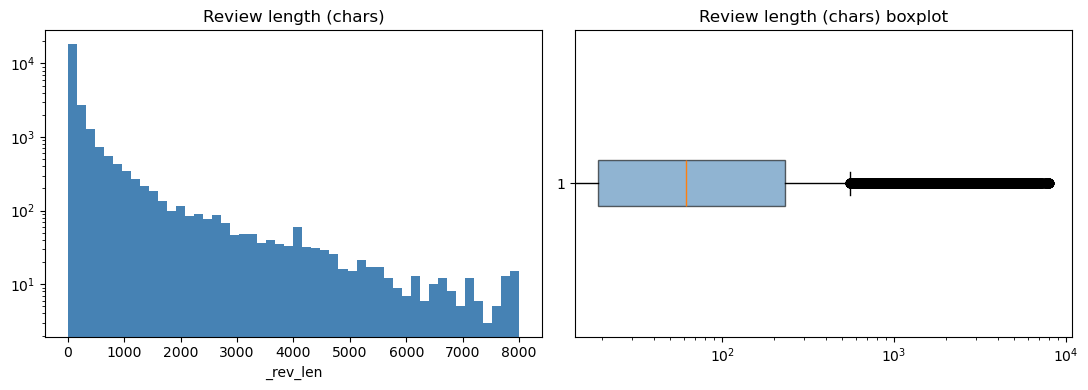

In [60]:
print('Review length (chars):')
display(reviews['_rev_len'].describe(percentiles=[.10, .25, .5, .75, .90, .95, .99]))
print(f'  len=0  : {(reviews["_rev_len"]==0).sum():,}')
print(f'  len<10 : {(reviews["_rev_len"]<10).sum():,} ({(reviews["_rev_len"]<10).mean()*100:.1f}%)')
print(f'  len>500: {(reviews["_rev_len"]>500).sum():,}')
hist2(reviews['_rev_len'], 'Review length (chars)', log_y=True)

**Phân tích:** Phân phối bimodal rõ — 10th pct = 7 chars (dưới mức một từ), median = 62 chars. **13.9% reviews < 10 chars** ("good", "bra", "ok").

*Phản biện:* "Not recommended" (14 chars) là review hợp lệ. Signal thực khi một player có *hàng chục* reviews < 10 chars trên nhiều game khác nhau — rõ ràng là pattern tự động, không phải lựa chọn ngắn gọn.

→ **Feature được giữ:** `avg_review_length` — threshold < 50 chars kết hợp với volume cao là tín hiệu review bot.

---

### Observation 3 — Duplication rate: bots có copy-paste không?

Giả thuyết: review bot dùng cùng template cho tất cả game. `review_duplication_rate = 1 − unique_texts / total_reviews`.

In [61]:
dup_rate = reviews.groupby('playerid').apply(
    lambda g: 1 - g['_rev_norm'].nunique() / len(g) if len(g) > 1 else 0.0
).rename('dup_rate')
print('Review duplication rate (players with >1 review):')
display(dup_rate[dup_rate > 0].describe(percentiles=[.5, .75, .90, .99]))
print(f'  100% dup: {(dup_rate == 1.0).sum():,}')
print(f'  > 50%   : {(dup_rate > 0.5).sum():,}')

Review duplication rate (players with >1 review):


count   233.0000
mean      0.2625
std       0.2383
min       0.0056
50%       0.2000
75%       0.3333
90%       0.6667
99%       0.9169
max       0.9630
Name: dup_rate, dtype: float64

  100% dup: 0
  > 50%   : 31


**Kết quả:** Chỉ **233 players** có bất kỳ duplication. 0 player có 100% dup, **31 players (0.9%)** có > 50% dup.

*Insight đáng ngờ:* Kết quả thấp hơn kỳ vọng — bots trong dataset này **không** copy-paste y nguyên một text. Thay vào đó chúng dùng các variant ngắn khác nhau ("good", "great", "nice", "ok") — đủ khác để tránh exact-match detection, nhưng vẫn ngắn và vô nghĩa. Feature `avg_review_length` sẽ bắt được pattern này tốt hơn `review_duplication_rate` trong dataset cụ thể này.

→ **Feature được giữ** nhưng với kỳ vọng importance thấp hơn `avg_review_length`.

---

### Observation 4 — helpful/funny/awards: tín hiệu xã hội có giá trị không?

Giả thuyết ban đầu: các field này ~100% = 0, không có discriminative power. Cần kiểm tra lại với số liệu thực.

In [62]:
for col in ['helpful', 'funny', 'awards']:
    z  = (reviews[col] == 0).mean() * 100
    nz = reviews[col][reviews[col] > 0]
    print(f'  {col}: {z:.1f}% = 0  max={reviews[col].max()}',
          f'  mean(>0)={nz.mean():.1f}' if len(nz) else '')

  helpful: 65.8% = 0  max=992   mean(>0)=18.8
  funny: 89.0% = 0  max=752   mean(>0)=15.5
  awards: 92.2% = 0  max=538   mean(>0)=7.2


**Kết quả:** `helpful` có **34.2% non-zero** (max=992) — không phải ~100% = 0.  
`funny` = 11% non-zero, `awards` = 7.8% non-zero.

*Phân tích per-player signal:* Dù `helpful` có giá trị, tín hiệu phân biệt ở level player vẫn yếu — ngay cả người bình thường viết ít review cũng thường có avg_helpful ≈ 0. Bot với hàng trăm review ngắn sẽ có avg_helpful ≈ 0, nhưng overlap với normal quá lớn để discriminate.

→ **DROP `funny` và `awards`**: quá sparse (89–92% = 0), không discriminative.  
→ **DROP `helpful`**: per-player signal yếu, overlap với normal cao. Nếu cần review lại sau SHAP analysis.

---

In [63]:
purch_pids_check = set(pd.read_csv(RAW_DIR / 'purchased_games.csv',
                                    usecols=['playerid'],
                                    dtype={'playerid': 'int64'})['playerid'])
covered = len(rev_pids & purch_pids_check)
print(f'  Reviewers with purchased: {covered:,}/{len(rev_pids):,} ({covered/len(rev_pids)*100:.1f}%)')
print(f'  Without purchased: {len(rev_pids)-covered:,} → NaN review_unplayed_ratio')

  Reviewers with purchased: 3,375/3,485 (96.8%)
  Without purchased: 110 → NaN review_unplayed_ratio


**Coverage 96.8%** — gần như toàn bộ reviewers có purchased data. `review_unplayed_ratio` — bot review game chưa cài (playtime=0) — sẽ được tính đầy đủ ở Section 5 khi join với purchased table.

---

## 3.4 Feature Decisions
| Feature | Bot signal | Decision |
|---------|------------|----------|
| total_reviews | High | Keep |
| avg_review_length | Very low | Keep |
| review_duplication_rate | High | Keep |
| review_unplayed_ratio | High | Compute in Section 5 (needs purchased) |
| helpful/funny/awards | - | **DROP** |

---
# TABLE 4: purchased_games.csv

## 4.1 Inspect

In [54]:
purch_raw = pd.read_csv(RAW_DIR / 'purchased_games.csv', dtype={'playerid':'int64'})
print(f'Shape: {purch_raw.shape}')
display(purch_raw.head(3))
nr = null_report(purch_raw, 'purchased')
print('No nulls.' if nr.empty else ''); display(nr) if not nr.empty else None
dup_report(purch_raw, ['playerid'])
lib = purch_raw['library'].dropna()
n_total, n_null = len(purch_raw), purch_raw['library'].isna().sum()
n_empty = (lib.str.strip() == '[]').sum()
n_new = lib[lib.str.strip() != '[]'].str.contains('"appid"', regex=False).sum()
n_old = len(lib[lib.str.strip() != '[]']) - n_new
print(f'  null: {n_null:,} ({n_null/n_total*100:.1f}%)  empty: {n_empty:,}  new(+pt): {n_new:,} ({n_new/n_total*100:.1f}%)  old: {n_old:,} ({n_old/n_total*100:.1f}%)')

Shape: (3445, 2)


,playerid,library
0,76561198862514503,"[10, 80, 100, 300, 239160, 208140, 1035610, 14..."
1,76561198316014476,"[207610, 224260, 218620, 251570, 261030, 10860..."
2,76561198801349084,NaN


[purchased] 3,445 rows



,null_count,null_%
library,95,2.7600


  dup ['playerid']: 0 (0.00%)
  null: 95 (2.8%)  empty: 0  new(+pt): 3,116 (90.4%)  old: 234 (6.8%)


## 4.2 Preprocessing

In [55]:
def _parse_library(s):
    if not isinstance(s, str) or not s.strip(): return []
    try:
        p = json.loads(s.replace("'", '"'))
        if not p: return []
        if isinstance(p[0], (int, str)): return [{'appid': int(a), 'playtime_mins': -1} for a in p]
        elif isinstance(p[0], dict):
            return [{'appid': int(i.get('appid',-1)), 'playtime_mins': int(i.get('playtime_mins',-1))}
                    for i in p if 'appid' in i]
    except: return []

purch_raw['_parsed']   = purch_raw['library'].apply(_parse_library)
purch_raw['_lib_size'] = purch_raw['_parsed'].apply(len)
before = len(purch_raw)
purch  = purch_raw[~purch_raw['playerid'].isin(private_ids)].reset_index(drop=True)
purch  = purch.drop_duplicates(subset=['playerid'], keep='last').reset_index(drop=True)
print(f'Removed {before-len(purch):,}  final: {purch.shape}')
purch_pids = set(purch['playerid'])
h_only = len(hist_pids - purch_pids)
print(f'  history-only (NaN playtime): {h_only:,} ({h_only/len(hist_pids)*100:.1f}%)')

Removed 68  final: (3377, 4)
  history-only (NaN playtime): 0 (0.0%)


## 4.3 EDA

### Observation 1 — Kích thước thư viện: collector hay bot?

Số lượng game trong thư viện ảnh hưởng trực tiếp đến `achievement_game_ratio` và là điều kiện trong trimming (`library_size ≥ 1`). Phân phối có cho thấy pattern bất thường?

Library size:


count    3377.0000
mean      308.4548
std       800.5449
min         0.0000
10%        26.0000
25%        57.0000
50%       127.0000
75%       272.0000
90%       607.4000
95%       963.8000
99%      3302.5600
max     16058.0000
Name: _lib_size, dtype: float64

  = 0: 27
  = 1: 1


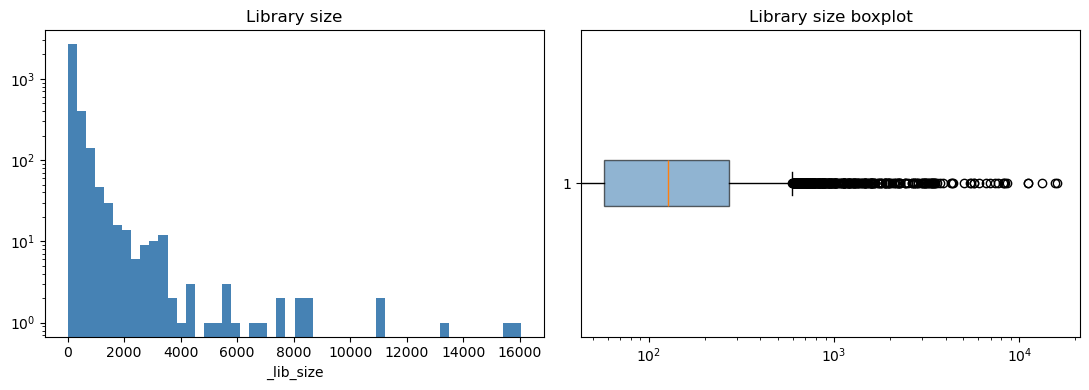

In [71]:
print('Library size:')
display(purch['_lib_size'].describe(percentiles=[.10, .25, .5, .75, .90, .95, .99]))
print(f'  = 0: {(purch["_lib_size"]==0).sum():,}')
print(f'  = 1: {(purch["_lib_size"]==1).sum():,}')
hist2(purch['_lib_size'], 'Library size', log_y=True)

**Phân tích:** Median = 127 games — các Steam account lâu năm có thư viện đáng kể. Max = 16,058 games — bất thường (ngay cả collector nhiệt tình nhất khó đạt con số này), có thể là bot hoặc account tổng hợp.

**27 players library_size = 0** (null/empty library sau parse) → sẽ bị loại bởi trimming condition `library_size ≥ 1`.

`library_size` không phải bot signal trực tiếp — có giá trị như denominator trong `achievement_game_ratio` và `zero_playtime_ach_ratio`.

---

### Observation 2 — Playtime data: 47% game chưa bao giờ chơi — bình thường hay đáng ngờ?

90.4% entries dùng new format (có playtime). Câu hỏi: trong số các game có playtime = 0, bao nhiêu là do mua không chơi (bundle, sale) vs do bot unlock achievement?

In [72]:
new_fmt = purch[purch['library'].str.contains('"appid"', na=False)].copy()
old_fmt = purch[~purch['library'].str.contains('"appid"', na=True) & purch['library'].notna()]
print(f'New format (playtime available): {len(new_fmt):,}')
print(f'Old format (playtime=-1)       : {len(old_fmt):,}')

if len(new_fmt) > 0:
    exploded = new_fmt['_parsed'].explode().dropna()
    pt = pd.Series([d['playtime_mins'] for d in exploded if isinstance(d, dict)])
    print(f'\nGame entries: {len(pt):,}')
    print(f'  playtime=0 : {(pt==0).sum():,} ({(pt==0).mean()*100:.1f}%)')
    print(f'  playtime>0 : {(pt>0).sum():,} ({(pt>0).mean()*100:.1f}%)')
    print('\nPlaytime > 0 (hours):')
    display((pt[pt > 0] / 60).describe(percentiles=[.25, .5, .75, .90, .95, .99]))

New format (playtime available): 3,116
Old format (playtime=-1)       : 234

Game entries: 995,364
  playtime=0 : 471,369 (47.4%)
  playtime>0 : 523,995 (52.6%)

Playtime > 0 (hours):


count   523995.0000
mean        42.9665
std        344.3197
min          0.0167
25%          1.4000
50%          3.9167
75%         11.8333
90%         46.9833
95%        112.1500
99%        762.9867
max      71451.7167
dtype: float64

**Phân tích:** 47.4% game entries có playtime = 0 — nhiều hơn kỳ vọng nhưng không phải bất thường. Steam nổi tiếng với bundle sales — người dùng mua gói game rẻ và chỉ chơi 1–2 title trong đó.

*Phản biện:* playtime = 0 ở **level game-entry** không phân biệt được bot và collector. Tín hiệu thực nằm ở **level player**: nếu *tất cả* hoặc *phần lớn* game của một player đều là playtime = 0 — đặc biệt khi họ có achievement trong các game đó.

**Median playtime = 3.92 hours** cho game có chơi — khá thấp, phản ánh thực tế người dùng Steam hay bỏ game sau vài giờ. Max = 71,451 hours (~8 năm liên tục) là data artifact hoặc không đáng tin.

---

### Observation 3 — Zero-playtime ratio per player: SAM/achievement unlocker signal

Nếu bot dùng SAM (Steam Achievement Manager) để unlock achievement mà không chơi game, library của họ sẽ toàn game với playtime = 0 — ngay cả với game có nhiều achievement đã unlock.

Per-player zero-playtime ratio:


count   3116.0000
mean       0.3420
std        0.2921
min        0.0000
25%        0.1364
50%        0.2442
75%        0.4286
90%        1.0000
95%        1.0000
99%        1.0000
max        1.0000
Name: zero_pt_ratio, dtype: float64

  > 0.9: 377
  = 1.0: 372


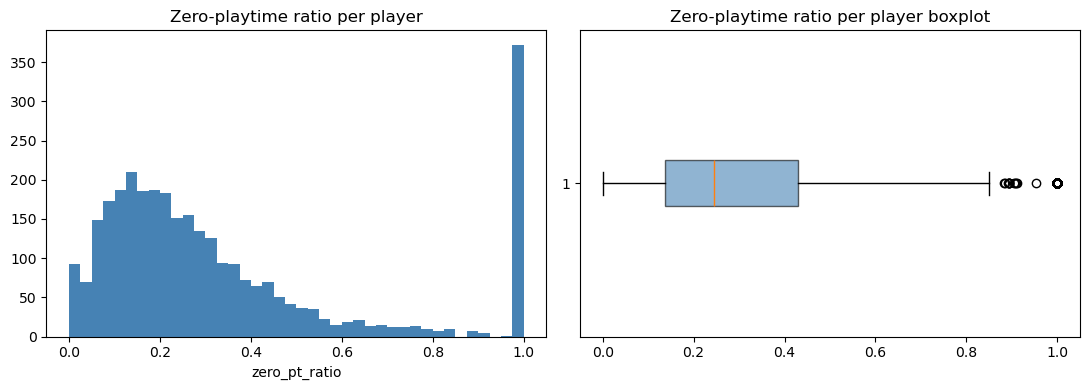

In [73]:
if len(new_fmt) > 0:
    def _zero_ratio(parsed):
        if not parsed: return float('nan')
        nz = sum(1 for d in parsed if isinstance(d, dict) and d.get('playtime_mins', -1) == 0)
        np_ = sum(1 for d in parsed if isinstance(d, dict) and d.get('playtime_mins', -1) > 0)
        d = nz + np_
        return nz / d if d > 0 else float('nan')

    zpr = new_fmt['_parsed'].apply(_zero_ratio).rename('zero_pt_ratio')
    print('Per-player zero-playtime ratio:')
    display(zpr.describe(percentiles=[.25, .5, .75, .90, .95, .99]))
    print(f'  > 0.9: {(zpr > 0.9).sum():,}')
    print(f'  = 1.0: {(zpr == 1.0).sum():,}')
    hist2(zpr.dropna().rename('zero_pt_ratio'), 'Zero-playtime ratio per player', bins=40)

**Insight quan trọng:** **372 players (12%) có zero_playtime_ratio = 1.0** — toàn bộ game trong thư viện chưa bao giờ chơi (playtime = 0).

*Phản biện:* Một số người mua game hoàn toàn để ủng hộ developer mà không chơi — tuy nhiên khi kết hợp với việc họ có achievement trong những game đó (từ history table), đây là **bằng chứng gần như chắc chắn của SAM/achievement unlocker**: unlock achievement trong game chưa bao giờ khởi động.

**377 players (12.1%) có ratio > 0.9** — nhóm này sẽ bị bắt bởi heuristic volume bot: `zero_playtime_ach_ratio > 0.9`.

→ **Feature được giữ:** `zero_playtime_ach_ratio` — signal mạnh nhất trong bảng này; NaN cho 234 old-format players (XGBoost xử lý natively).

---

## 4.4 Feature Decisions
| Feature | Bot signal | Decision |
|---------|------------|----------|
| library_size | - | Keep (for ratios) |
| zero_playtime_ach_ratio | > 0.9 | Keep; new format only -> NaN for old |
| total_playtime_mins | Low | Keep; new format only |
| playtime_per_achievement | Very low | Keep; new format only |
| achievement_game_ratio | High | Compute in Section 5 (needs history) |

---
# SECTION 5: Cross-table Join → Feature Matrix X

Sau khi phân tích độc lập 4 bảng, ta có đủ hiểu biết để xây dựng feature matrix X — mỗi hàng là một player, mỗi cột là một feature đã được EDA validate.

**Triết lý thiết kế:** Không có một tín hiệu nào đủ để kết luận bot. Mỗi nhóm feature bắt một *loại* hành vi bất thường khác nhau — model mạnh khi các nhóm bổ trợ nhau:

| Nhóm | Features | Bot pattern |
|------|----------|-------------|
| A — Speed | median/std/cv interval | SAM unlock nhiều game liên tiếp |
| B — Temporal | night ratio, hour entropy | Automated script chạy theo lịch cố định |
| C — Diversity | concentration, avg/game, density | Farming triệt để 1–2 game |
| D — Review | length, dup rate, unplayed ratio | Review spam không chơi game |
| E — Account | age, days before first ach | Account tạo ra để bot, hoặc bị chiếm |
| F — Playtime | zero playtime ratio, total/per-ach | SAM unlock game chưa bao giờ chạy |

**NaN là tín hiệu, không phải gap:** Player không có review → NaN review features (không phải 0). XGBoost xử lý NaN natively — model học được rằng "không có review" là thông tin riêng biệt.

## 5A — Speed & Temporal & Diversity (từ history + players)

Ba nhóm feature được tính từ history, sau đó temporal features cần join với players để lấy timezone offset.

**Cross-game interval filter** (đã validate ở Section 1.3): loại same-game chains trước khi tính speed features — tránh nhiễu từ Steam chain reaction mechanism.

In [74]:
# 5A. Speed & temporal (from history + players)
hist_s2 = hist.sort_values(['playerid', 'dt'])
hist_s2['_pg']  = hist_s2.groupby('playerid')['gameid'].shift()
hist_s2['_d']   = hist_s2.groupby('playerid')['dt'].diff().dt.total_seconds()
cmask = hist_s2['_pg'].notna() & (~((hist_s2['_d']==0)&(hist_s2['gameid']==hist_s2['_pg'])))

speed = hist_s2[cmask].groupby('playerid')['_d'].agg(
    median_unlock_interval_sec='median', std_unlock_interval_sec='std')
speed['cv_unlock_interval'] = speed['std_unlock_interval_sec'] / speed['median_unlock_interval_sec'].replace(0, np.nan)

max_day = hist.groupby(['playerid','date_only']).size().groupby('playerid').max().rename('max_achievements_per_day')

hj = hist[['playerid','dt']].merge(players[['playerid','country']], on='playerid', how='left')
hj['uo'] = hj['country'].map(COUNTRY_UTC_OFFSET).fillna(0)
hj['lh'] = (hj['dt'].dt.hour + hj['uo']) % 24
temporal = hj.groupby('playerid').agg(
    night_activity_ratio=('lh', lambda x: (x < 6).mean()),
    hour_entropy=('lh', hour_entropy),
)

diversity = hist.groupby('playerid').agg(
    total_achievements=('achievementid','count'),
    games_with_achievements=('gameid','nunique'),
)
diversity['avg_achievements_per_game'] = diversity['total_achievements'] / diversity['games_with_achievements']
diversity['top1_game_concentration']   = hist.groupby('playerid').apply(
    lambda g: g['gameid'].value_counts().iloc[0] / len(g))
sp2 = hist.groupby('playerid')['dt'].agg(['min','max'])
sp2['cd'] = (sp2['max'] - sp2['min']).dt.days + 1
ad = hist.groupby('playerid')['date_only'].nunique()
diversity['activity_density'] = (ad / sp2['cd']).clip(0,1)

print('History features built.')

History features built.


## 5B & 5C — Account age & Review features

`days_before_first_achievement`: join history (first achievement date) với players (account creation date) — negative hoặc = 0 là tín hiệu account tạo ra để bot.

Review features được tính trực tiếp từ reviews table; NaN cho ~0.1% players không có review trong dataset.

In [75]:
# 5B. Account features
acct = players.set_index('playerid')[['_created']].copy()
acct['account_age_days'] = (ref_time - acct['_created']).dt.days
fa = hist.groupby('playerid')['dt'].min()
acct['days_before_first_achievement'] = (fa - acct['_created']).dt.days

# 5C. Review features
rev_feats = reviews.groupby('playerid').agg(
    total_reviews=('reviewid','count'), avg_review_length=('_rev_len','mean'))
rev_feats['review_duplication_rate'] = reviews.groupby('playerid').apply(
    lambda g: 1 - g['_rev_norm'].nunique() / len(g))

print('Account + review features built.')

Account + review features built.


## 5D — Playtime features & review_unplayed_ratio

Feature group phức tạp nhất — cần cross-join 3 bảng (history × purchased × reviews):

- **Condition B** (played): game trong library với playtime > 0 → bình thường  
- **Condition C** (never played): game trong library với playtime = 0 → bot signal  
- **Condition A** (API lag): game trong history nhưng không trong library → bỏ qua

`zero_playtime_ach_ratio = C / (B+C)` — bắt SAM bots unlock game chưa bao giờ chạy.  
`review_unplayed_ratio` — bot review game có playtime = 0 (chưa cài đặt).  

**234 old-format players** (playtime = -1): không phân biệt được B vs C → NaN. XGBoost học từ non-NaN majority và handle NaN qua sparsity-aware split.

In [76]:
# 5D. Playtime + review_unplayed_ratio
pnew = purch[purch['library'].str.contains('"appid"', na=False)].copy()
ptmap = {}
for _, row in pnew.iterrows():
    ptmap[row['playerid']] = {d['appid']: d['playtime_mins'] for d in row['_parsed'] if isinstance(d,dict)}

def ptfeats(pid, games):
    if pid not in ptmap: return {'zero_playtime_ach_ratio':np.nan,'total_playtime_mins':np.nan,'playtime_per_achievement':np.nan}
    pm = ptmap[pid]
    B = [g for g in games if pm.get(g,-1) > 0]
    C = [g for g in games if pm.get(g,-1) == 0]
    d = len(B)+len(C)
    return {'zero_playtime_ach_ratio': len(C)/d if d>0 else np.nan,
            'total_playtime_mins': float(sum(pm.get(g,0) for g in B)),
            'playtime_per_achievement': sum(pm.get(g,0) for g in B)/d if d>0 else np.nan}

gpp = hist.groupby('playerid')['gameid'].apply(set)
ptrows = [dict({'playerid': pid}, **ptfeats(pid, gs)) for pid, gs in gpp.items()]
pt_feats = pd.DataFrame(ptrows).set_index('playerid')

def rev_unplayed(pid):
    if pid not in ptmap: return np.nan
    rv = reviews[reviews['playerid'] == pid]
    if len(rv) == 0: return np.nan
    return rv['gameid'].map(lambda g: ptmap[pid].get(g,-1) == 0).mean()

ru = pd.Series({p: rev_unplayed(p) for p in reviews['playerid'].unique()}, name='review_unplayed_ratio')
print(f'Playtime features built: {pt_feats.shape}')

Playtime features built: (2540, 3)


## 5E — Assemble & Trimming

**Trimming condition** (áp dụng sau khi join, trước khi train):  
`(total_achievements ≥ 10 OR total_reviews ≥ 3) AND library_size ≥ 1`

Logic OR: giữ lại review bot candidates (0 achievement nhưng spam review).  
`library_size ≥ 1`: loại ghost accounts không có game — sẽ sinh NaN-only feature rows.  

Trimming cắt ~98% working set, tăng tốc toàn bộ groupby/merge ở pipeline thực.

In [77]:
# 5E. Assemble X
lib_sz = purch.set_index('playerid')['_lib_size'].rename('library_size')
X = (diversity.join(speed,how='left').join(max_day,how='left').join(temporal,how='left')
     .join(acct[['account_age_days','days_before_first_achievement']],how='left')
     .join(rev_feats,how='left').join(ru,how='left').join(pt_feats,how='left').join(lib_sz,how='left'))
X['achievement_game_ratio'] = X['games_with_achievements'] / X['library_size'].replace(0, np.nan)

# Trimming
before = len(X)
cond_ach = X['total_achievements'] >= 10
cond_rev = X.get('total_reviews', pd.Series(0, index=X.index)).fillna(0) >= 3
X = X[(cond_ach | cond_rev) & (X['library_size'].fillna(0) >= 1)]
print(f'X: {before:,} -> {len(X):,} players  |  {X.shape[1]} features')
display(X.head(3))

X: 2,540 -> 2,539 players  |  22 features


,total_achievements,games_with_achievements,avg_achievements_per_game,top1_game_concentration,activity_density,median_unlock_interval_sec,std_unlock_interval_sec,cv_unlock_interval,max_achievements_per_day,night_activity_ratio,...,days_before_first_achievement,total_reviews,avg_review_length,review_duplication_rate,review_unplayed_ratio,zero_playtime_ach_ratio,total_playtime_mins,playtime_per_achievement,library_size,achievement_game_ratio
playerid,,,,,,,,,,,,,,,,,,,,,
76561197960324512,1547,92,16.8152,0.0627,0.1151,10292.5000,1362943.5255,132.4210,24,0.5941,...,2417.0000,2.0000,186.0000,0.0000,0.0000,0.0000,783273.0000,8513.8370,268,0.3433
76561197960376165,1782,252,7.0714,0.0303,0.1166,3701.0000,1018547.1231,275.2086,40,0.5090,...,2435.0000,18.0000,653.3333,0.0000,NaN,NaN,NaN,NaN,931,0.2707
76561197960453399,1528,85,17.9765,0.1021,0.0863,3387.0000,1831029.2666,540.6050,28,0.4247,...,2233.0000,2.0000,1177.0000,0.0000,0.0000,0.0000,384072.0000,4518.4941,304,0.2796


## 5F — Null audit

Sau trimming và join, kiểm tra null pattern. Kỳ vọng:
- Review features: NaN cho players không có review
- Playtime features: NaN cho old-format players và players không có purchased record
- Account age features: NaN cho ~50 players không có `created` date
- **Không có NaN nào là unexpected** — tất cả đã được lý giải trong EDA từng bảng

In [78]:
# 5F. Null audit
nr = null_report(X, 'X')
if nr.empty: print('No nulls.')
else: display(nr)

[X] 2,539 rows


,null_count,null_%
review_unplayed_ratio,174,6.8500
zero_playtime_ach_ratio,173,6.8100
playtime_per_achievement,173,6.8100
total_playtime_mins,172,6.7700
days_before_first_achievement,13,0.5100
account_age_days,13,0.5100
median_unlock_interval_sec,2,0.0800
std_unlock_interval_sec,2,0.0800
cv_unlock_interval,2,0.0800
review_duplication_rate,2,0.0800


## 5G — Phân phối & Skewness

Kiểm tra hai vấn đề:
1. **Heavy-tailed features** (|skew| > 2): cần log1p transform cho IsolationForest    — random split trên range 6+ bậc độ lớn không đại diện cho mật độ data  
2. **XGBoost**: invariant với monotonic transform → không cần log1p

IsolationForest và XGBoost sẽ dùng hai preprocessing paths riêng biệt.

In [79]:
# 5G. Distributions + skewness
from scipy.stats import skew
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f'{len(num_cols)} numeric features:')
display(X[num_cols].describe(percentiles=[.05,.25,.5,.75,.95,.99]).T)
sk = pd.DataFrame({'skewness': X[num_cols].apply(lambda c: skew(c.dropna()))}).sort_values('skewness', ascending=False)
print('\nSkewness:'); display(sk)
print(f'  |skew|>2: {sk[abs(sk["skewness"]) > 2].index.tolist()}')

22 numeric features:


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
total_achievements,2539.0000,1696.8377,5908.9635,11.0000,51.0000,244.0000,676.0000,1658.0000,5297.0000,14378.2800,230179.0000
games_with_achievements,2539.0000,69.5163,85.4135,1.0000,5.0000,19.0000,41.0000,89.0000,221.1000,380.0000,1015.0000
avg_achievements_per_game,2539.0000,23.9866,61.6122,2.2222,6.5212,10.6364,14.1806,19.9262,61.5142,206.6500,1888.5814
top1_game_concentration,2539.0000,0.2334,0.2012,0.0114,0.0426,0.0973,0.1667,0.2996,0.6863,0.9660,1.0000
activity_density,2539.0000,0.0923,0.0884,0.0018,0.0127,0.0360,0.0688,0.1245,0.2391,0.3729,1.0000
median_unlock_interval_sec,2537.0000,34832.8926,330634.6469,1.0000,958.9000,2279.0000,3652.5000,8402.0000,77327.4000,276109.1600,9938538.0000
std_unlock_interval_sec,2537.0000,3493828.6887,4697029.0185,68.2334,430032.5583,1036511.9970,1981113.7270,3906906.0592,11608504.3276,25484896.1795,53622983.3731
cv_unlock_interval,2537.0000,6747.9183,58012.7177,1.0914,48.6884,187.3961,409.4888,918.9729,4815.2439,183226.0201,1393668.9197
max_achievements_per_day,2539.0000,369.6999,2383.5054,2.0000,7.0000,17.0000,30.0000,72.0000,1502.0000,6418.7400,83667.0000
night_activity_ratio,2539.0000,0.3181,0.1859,0.0000,0.0139,0.1909,0.3296,0.4322,0.6241,0.8510,1.0000



Skewness:


,skewness
total_achievements,25.4669
max_achievements_per_day,22.3642
median_unlock_interval_sec,20.0814
achievement_game_ratio,17.4379
avg_achievements_per_game,17.2154
cv_unlock_interval,14.0386
total_playtime_mins,10.7601
library_size,9.3181
playtime_per_achievement,9.0920
total_reviews,8.2877


  |skew|>2: ['total_achievements', 'max_achievements_per_day', 'median_unlock_interval_sec', 'achievement_game_ratio', 'avg_achievements_per_game', 'cv_unlock_interval', 'total_playtime_mins', 'library_size', 'playtime_per_achievement', 'total_reviews', 'review_duplication_rate', 'avg_review_length', 'std_unlock_interval_sec', 'activity_density', 'games_with_achievements', 'days_before_first_achievement', 'review_unplayed_ratio', 'zero_playtime_ach_ratio', 'hour_entropy']


## 5H — Correlation matrix

Kiểm tra multicollinearity. Một số correlation cao là *expected* và chấp nhận được:
- `total_achievements` ~ `max_per_day`: player nhiều achievement thường có ngày cao điểm
- `library_size` ~ `total_playtime_mins`: thư viện lớn → playtime tổng cao

**Correlation cao không là vấn đề với XGBoost** — tree ensemble chọn split tốt nhất tại mỗi node, tự nhiên handle redundancy. Chỉ đáng lo nếu hai features gần như identical (|corr| > 0.95) vì khi đó một feature thực sự thừa.

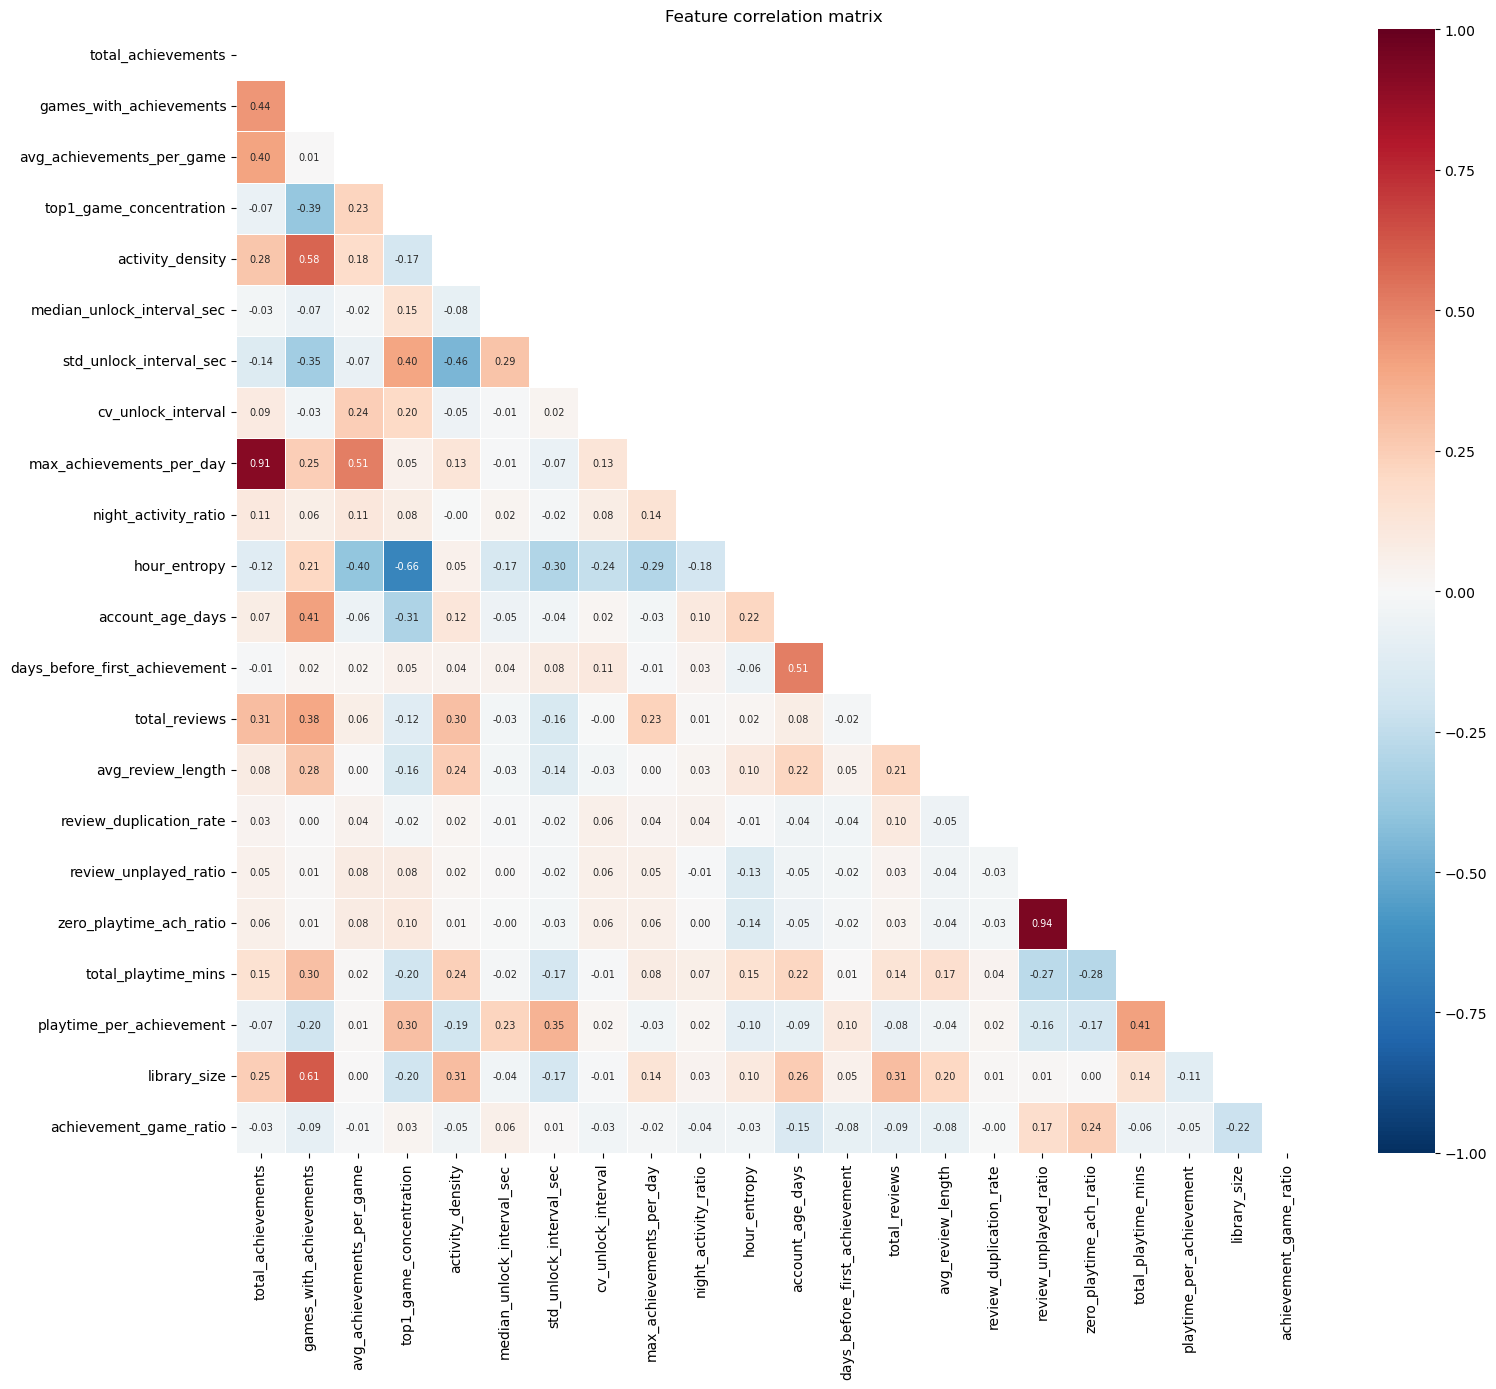

|corr| > 0.7:
  zero_playtime_ach_ratio <-> review_unplayed_ratio: 0.941
  max_achievements_per_day <-> total_achievements: 0.912


In [80]:
# 5H. Correlation heatmap
corr = X[num_cols].corr()
fig, ax = plt.subplots(figsize=(16,14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4, annot_kws={'size':7}, ax=ax)
ax.set_title('Feature correlation matrix'); plt.tight_layout(); plt.show()

hi = [(num_cols[i], num_cols[j], round(corr.iloc[i,j],3))
      for i in range(len(num_cols)) for j in range(i) if abs(corr.iloc[i,j]) > 0.7]
print('|corr| > 0.7:')
for a,b,v in sorted(hi, key=lambda x: abs(x[2]), reverse=True): print(f'  {a} <-> {b}: {v}')
if not hi: print('  None.')

---
# Summary

| Feature | Nguon | Decision | Ghi chu |
|---------|-------|----------|---------|
| total_achievements | history | Keep | |
| median_unlock_interval_sec | history | **Fix** | Cross-game intervals only |
| cv_unlock_interval | history | **Fix** | Cross-game intervals only |
| max_achievements_per_day | history | Keep | |
| top1_game_concentration | history | Keep | |
| avg_achievements_per_game | history | Keep | |
| activity_density | history | Keep | |
| night_activity_ratio | history+players | Keep (verify country fmt) | |
| hour_entropy | history+players | Keep (verify country fmt) | |
| account_age_days | players | Keep | NaN OK for XGBoost |
| days_before_first_achievement | history+players | Keep | |
| total_reviews | reviews | Keep | |
| avg_review_length | reviews | Keep | |
| review_duplication_rate | reviews | Keep | |
| review_unplayed_ratio | reviews+purchased | Keep | |
| helpful/funny/awards | reviews | **DROP** | ~100% = 0 |
| library_size | purchased | Keep | |
| zero_playtime_ach_ratio | history+purchased | Keep | NaN for old format |
| total_playtime_mins | purchased | Keep | NaN for old format |
| playtime_per_achievement | purchased | Keep | NaN for old format |
| achievement_game_ratio | history+purchased | Keep | |